# --- Model Architecture ---

In [1]:
# =========================================
# Environment Ingestion & Hardware Setup
# =========================================

import os
import sys
import torch
from pathlib import Path
from torchinfo import summary
import warnings
warnings.filterwarnings('ignore')

# Define root workspace paths
BASE_DIR = Path("/teamspace/studios/this_studio/airport-incident-detection")
SRC_DIR = BASE_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

PROC_DIR = str(BASE_DIR / "data" / "processed")

# Device Management Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔋 Execution Target Device: {device}")
if torch.cuda.is_available():
    print(f"    └── GPU Model Name: {torch.cuda.get_device_name(0)}")

%reload_ext autoreload
%autoreload 2

🔋 Execution Target Device: cuda
    └── GPU Model Name: Tesla T4


In [2]:
# ========================================
# Model Architecture & Layer Dimensions
# ========================================
from models.model import MultiTaskAirportNet

# Initialize the custom structural network
model = MultiTaskAirportNet().to(device)

# print("="*60 + "\n 🔬 CUSTOM MULTI-HEAD APRON DETECTOR ARCHITECTURE SUMMARY\n" + "="*60)
# # print(model)
# print("="*60)

# 2. Print Layer-by-Layer Architectural Matrix Layout
print("\n--- 🔬 CUSTOM MULTI-HEAD YOLO MODEL ARCHITECTURE SUMMARY ---")
model_stats = summary(
    model, 
    # FIX: Remove input_size entirely to bypass the forward execution graph pass
    input_size=(4, 3, 640, 640),
    col_names=["num_params", "trainable"],
    col_width=20,
    row_settings=["depth", "var_names"],
    verbose=0 # Blocks internal dummy tensor flow executions
)
print(model_stats)

--- 🏗️ SYNTHESIZING MULTI-TASK NETWORK ARCHITECTURE ---
 Locked early backbone layers successfully.
 All 3 specialized spatial task branches successfully configured.



--- 🔬 CUSTOM MULTI-HEAD YOLO MODEL ARCHITECTURE SUMMARY ---
Layer (type (var_name):depth-idx)                  Param #              Trainable
MultiTaskAirportNet (MultiTaskAirportNet)          --                   Partial
├─Sequential (backbone): 1-1                       --                   Partial
│    └─Conv2d (0): 2-1                             (9,408)              False
│    └─BatchNorm2d (1): 2-2                        (128)                False
│    └─ReLU (2): 2-3                               --                   --
│    └─MaxPool2d (3): 2-4                          --                   --
│    └─Sequential (4): 2-5                         --                   False
│    │    └─BasicBlock (0): 3-1                    (73,984)             False
│    │    └─BasicBlock (1): 3-2                    (73,984)             False
│    └─Sequential (5): 2-6                         --                   True
│    │    └─BasicBlock (0): 3-3                    230,144              True
│  

🔋 Execution Target Device: cuda
---🔍 INITIALIZED MULTI-TASK DATASET FOR SPLIT: [TRAIN] ---
✅ Bound Task [0] (turnaround): Registered 17702 frames.
✅ Bound Task [1] (ppe): Registered 20598 frames.
✅ Bound Task [2] (fod): Registered 61518 frames.
📊 Global Dataset Composition: Total registered multi-task sample frames = 99818

--- 🏗️ SYNTHESIZING MULTI-TASK NETWORK ARCHITECTURE ---
 Locked early backbone layers successfully.
 All 3 specialized spatial task branches successfully configured.

🚀 Starting Overfitting Test Run (50 Epochs)...
Epoch [01/50] -> Total Loss: 8.241765 | Turnaround Loss: 2.6536 | PPE Loss: 1.6626 | FOD Loss: 3.5348
Epoch [10/50] -> Total Loss: 0.197722 | Turnaround Loss: 0.0787 | PPE Loss: 0.0316 | FOD Loss: 0.0647
Epoch [20/50] -> Total Loss: 0.061612 | Turnaround Loss: 0.0262 | PPE Loss: 0.0123 | FOD Loss: 0.0075


Epoch [30/50] -> Total Loss: 0.031745 | Turnaround Loss: 0.0132 | PPE Loss: 0.0068 | FOD Loss: 0.0034
Epoch [40/50] -> Total Loss: 0.019889 | Turnaround Loss: 0.0081 | PPE Loss: 0.0045 | FOD Loss: 0.0018
Epoch [50/50] -> Total Loss: 0.014538 | Turnaround Loss: 0.0059 | PPE Loss: 0.0034 | FOD Loss: 0.0012
☑️ OVERFITTING TEST PASSED: Model safely optimized small sample batch vector!



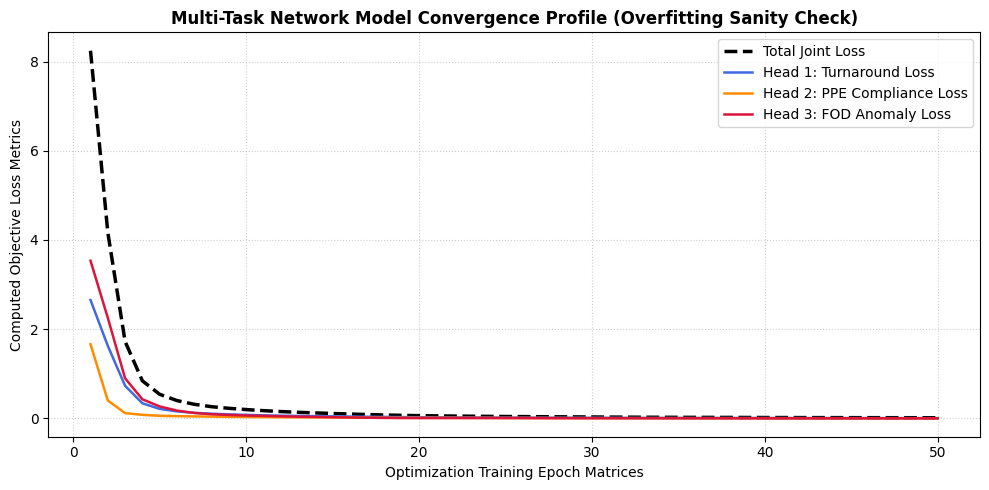

In [3]:
# -----------------------------------------
# Check Model Overfitting on Small sample
# -----------------------------------------
# from models.debug_overfit import run_overfitting_test

# # Invokes your isolated execution loop to run 50 memorization steps on a single batch
# run_overfitting_test()

from models.overfit_test import run_overfitting_check

run_overfitting_check(PROC_DIR)

In [4]:
from models.train import model_train_phase1

model_train_phase1(PROC_DIR)

🚀 Initializing Full-Scale Training Pipeline on Target: cuda
---🔍 INITIALIZED MULTI-TASK DATASET FOR SPLIT: [TRAIN] ---
✅ Bound Task [0] (turnaround): Registered 17702 frames.
✅ Bound Task [1] (ppe): Registered 20598 frames.
✅ Bound Task [2] (fod): Registered 61518 frames.
📊 Global Dataset Composition: Total registered multi-task sample frames = 99818

---🔍 INITIALIZED MULTI-TASK DATASET FOR SPLIT: [VAL] ---
✅ Bound Task [0] (turnaround): Registered 2697 frames.
✅ Bound Task [1] (ppe): Registered 3141 frames.
✅ Bound Task [2] (fod): Registered 9364 frames.
📊 Global Dataset Composition: Total registered multi-task sample frames = 15202

--- 🏗️ SYNTHESIZING MULTI-TASK NETWORK ARCHITECTURE ---
 Locked early backbone layers successfully.
 All 3 specialized spatial task branches successfully configured.

📅 Epoch [1/20]


  Training Progress:   0%|          | 6/6239 [00:02<29:18,  3.54it/s, Total Loss=5.9383]   

  Training Progress: 100%|██████████| 6239/6239 [15:17<00:00,  6.80it/s, Total Loss=1.9227] 


    📊 Summary -> Train Loss: 3.4005 | Val Loss: 0.5748
    └─ Heads Breakdown -> Turnaround: 0.6301 | PPE: 1.2171 | FOD: 1.2594
 💾 New optimal validation milestone secured. Checkpoint saved.

📅 Epoch [2/20]


  Training Progress: 100%|██████████| 6239/6239 [15:10<00:00,  6.85it/s, Total Loss=2.2500] 


...

    📊 Summary -> Train Loss: 0.4588 | Val Loss: 0.1638
    └─ Heads Breakdown -> Turnaround: 0.0189 | PPE: 0.2800 | FOD: 0.0207

📅 Epoch [19/20]


  Training Progress: 100%|██████████| 6239/6239 [15:29<00:00,  6.71it/s, Total Loss=0.2511]


    📊 Summary -> Train Loss: 0.4729 | Val Loss: 0.1630
    └─ Heads Breakdown -> Turnaround: 0.0216 | PPE: 0.2859 | FOD: 0.0231
 💾 New optimal validation milestone secured. Checkpoint saved.

📅 Epoch [20/20]


  Training Progress: 100%|██████████| 6239/6239 [15:38<00:00,  6.64it/s, Total Loss=1.2086] 


    📊 Summary -> Train Loss: 0.4782 | Val Loss: 0.1667
    └─ Heads Breakdown -> Turnaround: 0.0224 | PPE: 0.2884 | FOD: 0.0242

☑️ Training Sequence Concluded Successfully.


In [5]:
from models.train import model_train_phase2

model_train_phase2(PROC_DIR)

🚀 Initializing Phase 2: Targeted FOD Fine-Tuning on Target: cuda
---🔍 INITIALIZED MULTI-TASK DATASET FOR SPLIT: [TRAIN] ---
✅ Bound Task [0] (turnaround): Registered 17702 frames.
✅ Bound Task [1] (ppe): Registered 20598 frames.
✅ Bound Task [2] (fod): Registered 61518 frames.
📊 Global Dataset Composition: Total registered multi-task sample frames = 99818

---🔍 INITIALIZED MULTI-TASK DATASET FOR SPLIT: [VAL] ---
✅ Bound Task [0] (turnaround): Registered 2697 frames.
✅ Bound Task [1] (ppe): Registered 3141 frames.
✅ Bound Task [2] (fod): Registered 9364 frames.
📊 Global Dataset Composition: Total registered multi-task sample frames = 15202

--- 🏗️ SYNTHESIZING MULTI-TASK NETWORK ARCHITECTURE ---
 Locked early backbone layers successfully.
 All 3 specialized spatial task branches successfully configured.
💾 Phase 1 Base Weights Successfully Restored.
🔒 Locking Down Turnaround and PPE Branch Weights...

📅 Phase 2 - Epoch [1/10]


  Training Progress: 100%|██████████| 6239/6239 [14:47<00:00,  7.03it/s, Total Loss=0.0100]


KeyboardInterrupt: 